# APCG GGI Bilby Tutorial 
Caroline B. Owen

This is a brief tutorial on using Bilby to plot waveforms and perform parameter estimation, written for the 2026 Theoretical Aspects of Astroparticle Physics, Cosmology and Gravitation at the Galileo Galilei Institute for Theoretical Physics, Arcetri, Florence. 

Bilby is the Bayesian inference library used by the LVK collaboration to analyze their data.

The documentation for Bilby can be found <a href = "https://bilby-dev.github.io/bilby/index.html"> here </a>.

Other good resources are <a href = "https://arxiv.org/pdf/1811.02042"> this </a> paper by Ashton et al. and <a href = "https://arxiv.org/pdf/2006.00714"> this </a> one by Romero-Shaw et al. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import bilby 

In [2]:
# Specify the output directory and the label for the run.
outdir = "outdir"
label = "APCG_GGI_tutorial"
bilby.core.utils.setup_logger(outdir=outdir, label=label,log_level= "warning")

# Plotting Waveforms

We will begin by plotting the waveform in both the time and frequency domains.

In [3]:
# this function produces frequency and time domain gravitational wave signals observed at LIGO Hanford, given binary parameters 

def plotting_data(parameters):
    
    sampling_frequency = 2048.0
    minimum_frequency = parameters["minimum_frequency"]
    
    duration = bilby.gw.detector.get_safe_signal_duration(
        parameters['mass_1'],
        parameters['mass_2'],
        parameters['a_1'],
        parameters['a_2'],
        parameters['tilt_1'],
        parameters['tilt_2'],
        flow=minimum_frequency)

    end_time = parameters["geocent_time"] + 2 # it is standard to include 2 seconds after the merger for the ringdown 
    start_time = end_time - duration 

    # Fixed arguments passed into the source model
    waveform_arguments = dict(
        waveform_approximant="IMRPhenomPv2",
        reference_frequency=50.0,
        minimum_frequency=minimum_frequency,
)

    # Create the waveform_generator using a LAL BinaryBlackHole source function
    waveform_generator = bilby.gw.WaveformGenerator(
        start_time = start_time,
        duration=duration,
        sampling_frequency=sampling_frequency,
        frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
        parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
        waveform_arguments=waveform_arguments,
    )

    ifo = bilby.gw.detector.InterferometerList(["H1"])

    ifo.set_strain_data_from_zero_noise( 
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=start_time,
    );
    
    ifo.inject_signal(
    waveform_generator=waveform_generator, parameters=parameters
);

    print("SNR: {}".format(total_snr(ifo)))
    
    mask = ifo[0].frequency_mask
    frequencies = ifo[0].frequency_array[mask]
    fd_strain = abs(ifo[0].frequency_domain_strain[mask])

    times = ifo[0].time_array - parameters["geocent_time"]
    td_strain = ifo[0].time_domain_strain

    ISCO = 4.4e+3/(parameters["mass_1"]+parameters["mass_2"])

    output_dict = dict(
        frequency_array = frequencies,
        hplus_fd = fd_strain,
        time_array = times,
        hplus_td = td_strain,
        ISCO = ISCO
    )
    
    return output_dict

# this computes the total SNR for a signal observed by multiple detectors. SNRs add in quadrature 
def total_snr(ifo_list):
    snr_sqrd = 0
    for ifo in ifo_list:
        snr_sqrd += np.real(ifo.optimal_snr_squared(ifo.frequency_domain_strain))
    return np.sqrt(snr_sqrd)

/Users/cbo/Library/Python/3.11/lib/python/site-packages/bilby/gw/detector/__init__.py:25: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(True)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI


SNR: 57.45212057842871
SNR: 57.45212057842871


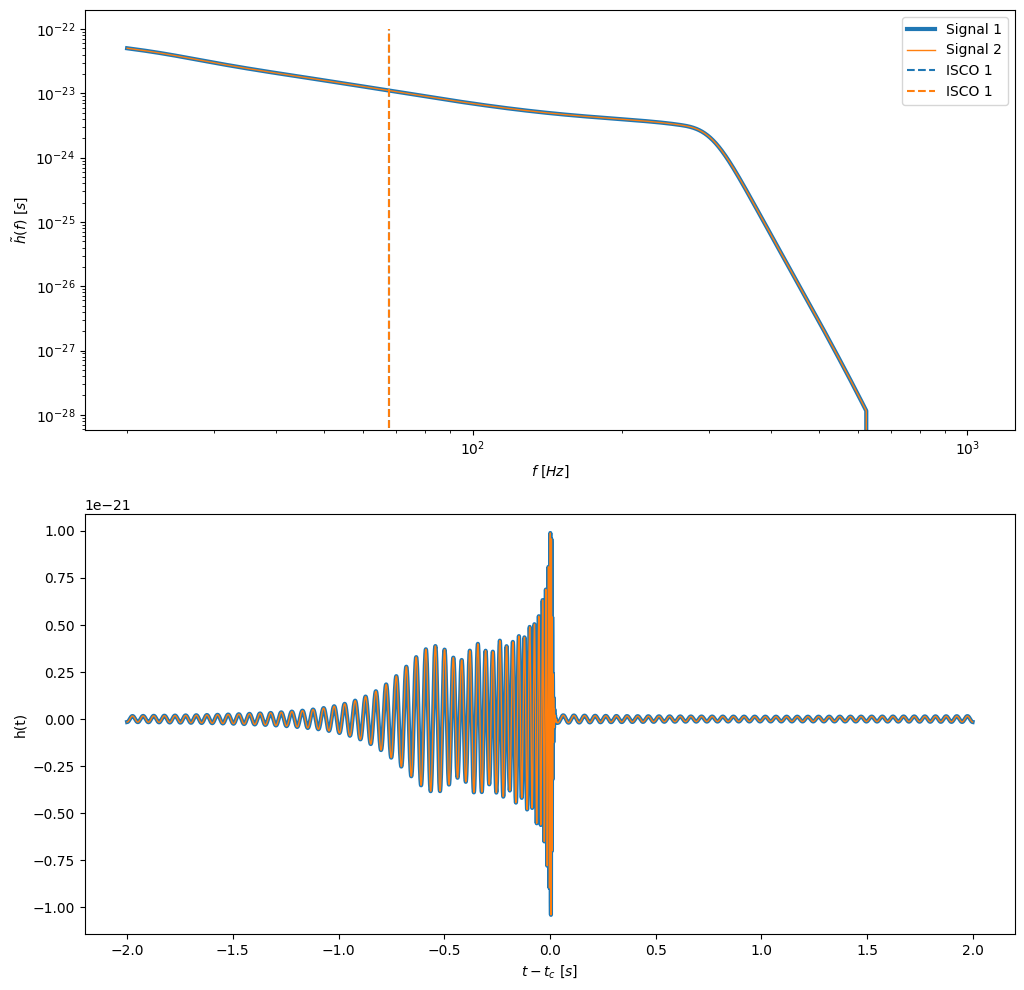

In [4]:
# one set of parameters, roughly consistent with GW150914 
parameters_1 = dict(
    # two mass parameters 
    mass_1=36.0,
    mass_2=29.0, 
    # six angular momentum paramters 
    a_1=0.4,
    a_2=0.3, 
    tilt_1=0.5, 
    tilt_2=1.0, 
    phi_12=1.7,
    phi_jl=0.3, 
    # angle between total angular momenum and line of sight
    theta_jn=0.4,
    # three parameters to locate the binary in space 
    luminosity_distance=410,
    ra=1.375,
    dec=-1.2108,
    # polarization angle 
    psi=2.659,
    # phase at the reference frequency 
    phase=1.3,
    # time of merger 
    geocent_time=1126259642.413,
)
# A signal we observe at the detector will also depend on sky location (ra and dec) and polarization angle (psi). 
# However, those parameters only enter the strain through the detector response function so we don't need to worry about them yet 

parameters_1["minimum_frequency"]=20

# produce the signals  
plot_data_1 =plotting_data(parameters_1)

# Here we produce a second set of parameters identical to the first
# you can change one or more injection parameters below by overwriting the entry  
parameters_2 = parameters_1.copy()
parameters_2["luminosity_distance"] = 410

plot_data_2=plotting_data(parameters_2)

# plot the waveforms 
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12,12))
axes[0].loglog(plot_data_1["frequency_array"],abs(plot_data_1["hplus_fd"]),label = "Signal 1",linewidth = 3)
axes[0].loglog(plot_data_2["frequency_array"],abs(plot_data_2["hplus_fd"]),label = "Signal 2",linewidth = 1)
axes[0].vlines(plot_data_1["ISCO"],0,1e-22,linestyle='--',color = "C0",label = "ISCO 1")
axes[0].vlines(plot_data_2["ISCO"],0,1e-22,linestyle='--',color = "C1",label = "ISCO 1")
axes[0].set_xlabel("$f~[Hz]$")
axes[0].set_ylabel("$\\tilde h(f) ~[s]$")
axes[0].legend()
axes[1].plot(plot_data_1["time_array"],plot_data_1["hplus_td"],linewidth = 3)
axes[1].plot(plot_data_2["time_array"],plot_data_2["hplus_td"],linewidth = 1)
axes[1].set_xlabel("$t - t_c~[s]$")
axes[1].set_ylabel("h(t)");
#axes[1].set_xlim(-1.5,.25)

## Questions 

What happens when the total mass of the binary increases? Decreases?

What happens when you change the luminosity distance?

What happens if you change the minimum frequency? What about the phase?

# Parameter Estimation 

In binary parameter estimation, we approximate the posterior probability distribution on the binary parameters given the observed data and a chosen waveform model. 

Bayes's theorem tells us that the posterior is 

$$P(\boldsymbol{\theta}|d,h) = \frac{P(d|\boldsymbol{\theta},h)P(\boldsymbol{\theta})}{P(d)}$$

$\boldsymbol{\theta}$ is a vector containing all of the binary parameters, i.e. masses, spins, distance, etc..

$h=h(\boldsymbol{\theta})$ models the signal as a function of the binary parameters. 

The evidence $P(d)$ is the overall probability of observing $d$. For our purposes, it is a normalization factor. 

The prior $P(\boldsymbol{\theta})$ is a probability distribution that contains our assumptions about the parameters before the observation is made. 

The likelihood $P(d|\boldsymbol{\theta},h)$ is the probability of observing $d$ given the $\boldsymbol{\theta}$ and $h$. We choose the likelihood based on our assumptions about the data generation process and the noise model. We assume that an observed signal is the sum of detector noise $n$ and signal produced by the binary $h(\boldsymbol{\theta})$

$$d = n + h(\boldsymbol{\theta})\,.$$

For our current ground-based detectors, we assume that $n$ is stationary and Gaussian in the frequency domain, so the relevant likelihood is 

$$
\begin{align}
P(d|\boldsymbol{\theta},h) \propto &~\exp \left[-\frac{1}{2}(n|n)\right]\\
\propto&~\exp \left[-\frac{1}{2}(d-h(\boldsymbol{\theta})|d-h(\boldsymbol{\theta})\right]
\end{align}$$

where 

 $$(a|b) = 4 \mathrm{Re} \int \frac{\tilde a(f) \tilde b^{*}(f)}{S_n(f)}df$$

is a noise-weighted inner product in the frequency domain, $S_n(f)$ is the power spectral density (PSD). This is why we need the waveform in the frequency domain $\tilde h (f)$ for parameter estimation.


To estimate the parameters, we stochastically sample from the binary posterior using methods such as Markov chain Monte Carlo (MCMC) or nested sampling. The result is a set of samples of $\boldsymbol{\theta}$ that are distributed according to $P(\boldsymbol{\theta}|d,h)$.


See 
<a href = "https://arxiv.org/pdf/1809.02293"> Talbot & Thrane </a> for a good overview of Bayesian parameter estimation in the context of gravitational waves. 

## Injection and Recovery 
Below is an example of an "injection and recovery": We construct, or inject, a synthetic gravitational wave signal, and then we attempt to recover the binary parameters. Because we know the parameters we started with, we can make sure our data analysis pipeline is working well before turning to real data. 

In [5]:
bilby.core.utils.setup_logger(outdir=outdir, label=label,)

In [6]:
injection_parameters = dict(
    # two mass parameters 
    mass_1=36.0,
    mass_2=29.0, 
    # six angular momentum paramters 
    a_1=0.4,
    a_2=0.3, 
    tilt_1=0.5, 
    tilt_2=1.0, 
    phi_12=1.7,
    phi_jl=0.3, 
    # angle between total angular momenum and line of sight
    theta_jn=0.4,
    # three parameters to locate the binary in space 
    luminosity_distance=2000.0,
    ra=1.375,
    dec=-1.2108,
    # polarization angle 
    psi=2.659,
    # phase at the reference frequency 
    phase=1.3,
    # time of merger 
    geocent_time=1126259642.413,
)

In [7]:
sampling_frequency = 2048.0 # the maximum freqency is half the sampling frequency (so 1024 in this case).  
                            # 2048.0 Hz is good for most stellar mass binaries, but for lower mass signals,  you may want to increase to 4096 
minimum_frequency = 20 # 20 Hz is the standard minimum frequency cutoff for current gravitational wave observations 

# the signal duration rounded up to the nearest power of 2
duration = bilby.gw.detector.get_safe_signal_duration(
    injection_parameters['mass_1'],
    injection_parameters['mass_2'],
    injection_parameters['a_1'],
    injection_parameters['a_2'],
    injection_parameters['tilt_1'],
    injection_parameters['tilt_2'],
    flow=minimum_frequency)

end_time = injection_parameters["geocent_time"] + 2 # it is standard to include 2 seconds after the merger time for the ringdown 
start_time = end_time - duration 

## The Likelihood 

The likelihood depends on the data $d$ and our chosen model $h(\boldsymbol{\theta})$

$$
\begin{align}
P(d|\boldsymbol{\theta},h)\propto&~\exp \left[-\frac{1}{2}(d-h(\boldsymbol{\theta})|d-h(\boldsymbol{\theta})\right]
\end{align}$$

First, we set up the "WaveformGenerator" which contains info about $h(\boldsymbol{\theta})$

In [8]:
waveform_arguments = dict(
    waveform_approximant="IMRPhenomPv2", #this is the name of the waveform approximant 
    reference_frequency=50.0, # \phi(f_{ref}) = \phi_c = injection_parameters["phase"]
    minimum_frequency=minimum_frequency,
)


waveform_generator = bilby.gw.WaveformGenerator(
    start_time = start_time,
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
    )

09:59 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


Then, we set up the detectors and produce the signal $d$. 

An instance of the Interferometer class contains information about the detector, its location, and its power spectral density.

In [9]:
ifos = bilby.gw.detector.InterferometerList(["H1", "L1"])
# H1 is LIGO Hanford, L1 is LIGO Livingston, V1 is Virgo, K1 is KAGRA 


## This sets up the data to have no noise. 
## We will start with this simplified case, but generally, you should inject your signal into noise 
ifos.set_strain_data_from_zero_noise( 
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=start_time,
);

# This function generates Gaussian noise from the PSD 
# Uncomment it and rerun the notebook produce an injection with noise 

# ifos.set_strain_data_from_power_spectral_densities( 
#     sampling_frequency=sampling_frequency,
#     duration=duration,
#     start_time=start_time,
# );

## And this is where we inject the signal into the data. We assume that the signal is h(\theta). 
ifos.inject_signal(
    waveform_generator=waveform_generator, parameters=injection_parameters
);

09:59 bilby INFO    : Injected signal in H1:
09:59 bilby INFO    :   optimal SNR = 11.78
09:59 bilby INFO    :   matched filter SNR = 11.78-0.00j
09:59 bilby INFO    :   mass_1 = 36.0
09:59 bilby INFO    :   mass_2 = 29.0
09:59 bilby INFO    :   a_1 = 0.4
09:59 bilby INFO    :   a_2 = 0.3
09:59 bilby INFO    :   tilt_1 = 0.5
09:59 bilby INFO    :   tilt_2 = 1.0
09:59 bilby INFO    :   phi_12 = 1.7
09:59 bilby INFO    :   phi_jl = 0.3
09:59 bilby INFO    :   theta_jn = 0.4
09:59 bilby INFO    :   luminosity_distance = 2000.0
09:59 bilby INFO    :   ra = 1.375
09:59 bilby INFO    :   dec = -1.2108
09:59 bilby INFO    :   psi = 2.659
09:59 bilby INFO    :   phase = 1.3
09:59 bilby INFO    :   geocent_time = 1126259642.413
09:59 bilby INFO    : Injected signal in L1:
09:59 bilby INFO    :   optimal SNR = 9.53
09:59 bilby INFO    :   matched filter SNR = 9.53-0.00j
09:59 bilby INFO    :   mass_1 = 36.0
09:59 bilby INFO    :   mass_2 = 29.0
09:59 bilby INFO    :   a_1 = 0.4
09:59 bilby INFO 

Below, we plot the signal in the time and frequency domains at each detector. Along with the amplitude spectral density (ASD), which is $\sqrt{S_n(f)}$

Rather than plotting  $|\tilde h(f)|$, we plot $2|\tilde h(f)|\sqrt{f}$ because the signal to noise ratio is

$$\rho = (h|h) = 4 \mathrm{Re} \int \frac{\tilde h(f) \tilde h^{*}(f)}{S_n(f)}df$$

and compairing $2|\tilde h(f)|\sqrt{f}$ to $\sqrt{S_n(f)}$ allows us to (sort of) estimate the SNR by eye. 

Total SNR: 15.150307022185102


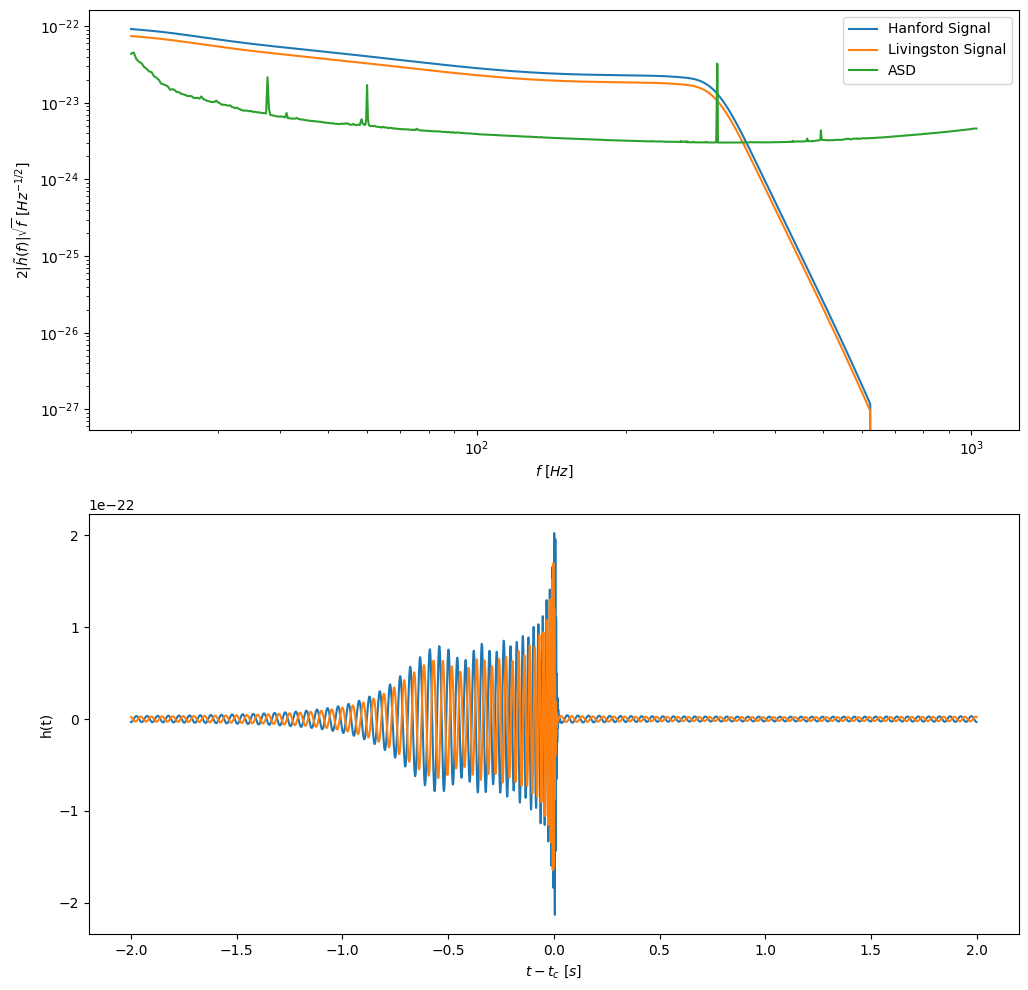

In [10]:
print("Total SNR: {}".format(total_snr(ifos)))

mask = ifos[0].frequency_mask # removes frequencies where there is no signal 
freqencies = ifos[0].frequency_array[mask]
fd_strain_h = ifos[0].frequency_domain_strain[mask]
fd_strain_l = ifos[1].frequency_domain_strain[mask]
asd =  ifos[0].amplitude_spectral_density_array[mask]

times = ifos[0].time_array - injection_parameters["geocent_time"]
td_strain_h = ifos[0].time_domain_strain
td_strain_l = ifos[1].time_domain_strain

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12,12))
axes[0].loglog(freqencies,2*abs(fd_strain_h)*np.sqrt(freqencies),label = "Hanford Signal")
axes[0].loglog(freqencies,2*abs(fd_strain_l)*np.sqrt(freqencies),label = "Livingston Signal")
axes[0].loglog(freqencies,asd,label = "ASD")
axes[0].set_xlabel("$f~[Hz]$")
axes[0].set_ylabel("$2|\\tilde h(f)|\sqrt{f}~[Hz^{-1/2}]$")
axes[0].legend()
axes[1].plot(times,td_strain_h)
axes[1].plot(times,td_strain_l)
axes[1].set_xlabel("$t - t_c~[s]$")
axes[1].set_ylabel("h(t)");
#axes[1].set_xlim(-1.25,.25);

Finally, we define the likelihood. 

In [11]:
likelihood = bilby.gw.GravitationalWaveTransient(
    interferometers=ifos, # this is the data  
    waveform_generator=waveform_generator # this is our model 
)
# We are currently using the same model and waveform generator that we used to produce the signal. 
# However, it is also possibl also possible to define a second waveform generator with different properties 

## The Priors

Bilby has default binary black hole priors, which are generally a good starting point, but you may need to overwrite some of them depending on what you are doing. They assume a uniform distribution on the component masses (with the restriction that $m_1$>$m_2$), but we sample on chirp mass $\mathcal{M}$ and mass ratio $q$. For the sake of time, we don't want to sample on all 15 parameters, so we will set the priors on 13 of them to delta functions at their injection value. 

In [12]:
priors = bilby.gw.prior.BBHPriorDict()

non_sampled_parameters =[
    "a_1",
    "a_2",
    "tilt_1",
    "tilt_2",
    "phi_12",
    "phi_jl",
    "psi",
    "luminosity_distance",
    "theta_jn",
    "ra",
    "dec",
    "geocent_time",
    "phase",
]

for key in non_sampled_parameters:
    priors[key] = injection_parameters[key]

for key in priors.keys():
    print(key+": {}".format(str(priors[key])))

09:59 bilby INFO    : No prior given, using default BBH priors in /Users/cbo/Library/Python/3.11/lib/python/site-packages/bilby/gw/prior_files/precessing_spins_bbh.prior.


mass_1: Constraint(minimum=5, maximum=100, name='mass_1', latex_label='$m_1$', unit=None)
mass_2: Constraint(minimum=5, maximum=100, name='mass_2', latex_label='$m_2$', unit=None)
mass_ratio: bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.125, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None, equal_mass=False)
chirp_mass: bilby.gw.prior.UniformInComponentsChirpMass(minimum=25, maximum=100, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
luminosity_distance: 2000.0
dec: -1.2108
ra: 1.375
theta_jn: 0.4
psi: 2.659
phase: 1.3
a_1: 0.4
a_2: 0.3
tilt_1: 0.5
tilt_2: 1.0
phi_12: 1.7
phi_jl: 0.3
geocent_time: 1126259642.413


Below, we plot the mass priors in terms of $m_1$ and $m_2$ and also in terms of $q$ and $\mathcal{M}$

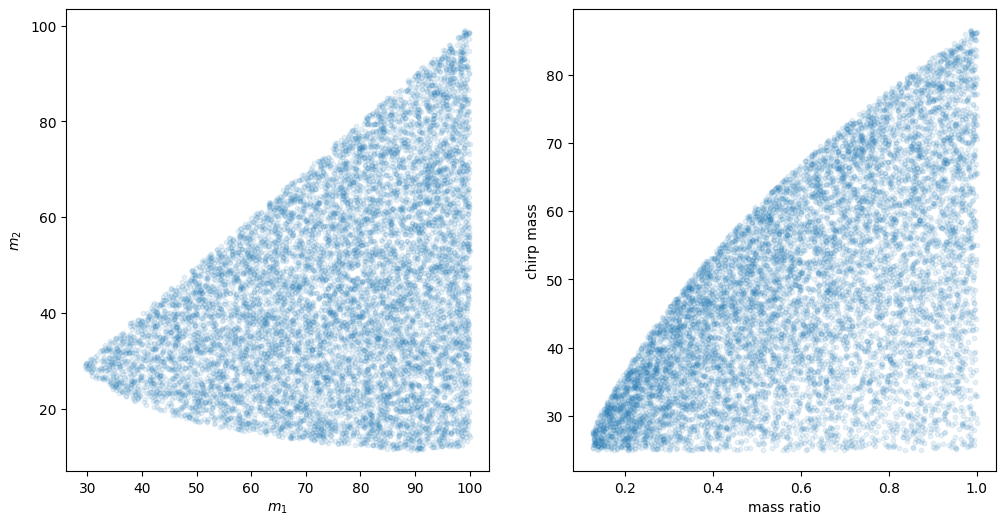

In [13]:
def conversion_function(parameters):
    converted_parameters = parameters.copy()
    converted_parameters["mass_1"],converted_parameters["mass_2"] = bilby.gw.conversion.chirp_mass_and_mass_ratio_to_component_masses(parameters['chirp_mass'], parameters['mass_ratio'])
    return converted_parameters

prior_samps = conversion_function(priors.sample(10000));

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
axes[0].scatter(prior_samps["mass_1"],prior_samps["mass_2"],alpha=0.1, s=10)
axes[0].set_xlabel("$m_1$")
axes[0].set_ylabel("$m_2$")
axes[1].scatter(prior_samps["mass_ratio"],prior_samps["chirp_mass"],alpha=0.1, s=10)
axes[1].set_xlabel("mass ratio")
axes[1].set_ylabel("chirp mass");

## The sampler and results

09:59 bilby INFO    : Running for label 'APCG_GGI_tutorial', output will be saved to 'outdir'
09:59 bilby INFO    : Using lal version 7.4.1
09:59 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.21;Id: cc61d073d248e45c3c75d3732ee642448f7bc008;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
09:59 bilby INFO    : Using lalsimulation version 5.3.1
09:59 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.21;Id: cc61d073d248e45c3c75d3732ee642448f7bc008;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
09:59 bilby INFO    : Analysis priors:
09:59 bilby INFO    : mass_ratio=bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.125, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None, equal_mass=False)
09:59 bilby INFO    : chirp_mass=bilby.gw.prior.UniformInComponentsChirpMass(minimum=25, maximum=100, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boun

1261it [00:49, 24.70it/s, bound:27 nc: 12 ncall:1.8e+04 eff:7.0% logz-ratio=104.46+/-0.30 dlogz:0.102>0.1]   

10:00 bilby INFO    : Written checkpoint file outdir/APCG_GGI_tutorial_resume.pickle


1263it [00:50, 24.87it/s, bound:27 nc:  1 ncall:1.8e+04 eff:7.6% logz-ratio=104.55+/-0.29 dlogz:0.001>0.1]

10:00 bilby INFO    : Rejection sampling nested samples to obtain 283 posterior samples
10:00 bilby INFO    : Sampling time: 0:00:50.737715
10:00 bilby INFO    : Computing per-detector log likelihoods.


...

10:00 bilby INFO    : Generating sky frame parameters.



100%|██████████████████████████████████████████████████████████████████████████████████████████████| 283/283 [00:00<00:00, 29329.35it/s]

10:00 bilby INFO    : Computing SNRs for every sample.



100%|████████████████████████████████████████████████████████████████████████████████████████████████| 283/283 [00:00<00:00, 331.69it/s]


10:00 bilby INFO    : Summary of results:
nsamples: 283
ln_noise_evidence: -114.766
ln_evidence: -10.212 +/-  0.354
ln_bayes_factor: 104.554 +/-  0.354

10:00 bilby INFO    : Generating waveform figure for H1
10:00 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
10:00 bilby INFO    : Generating waveform figure for L1
10:00 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


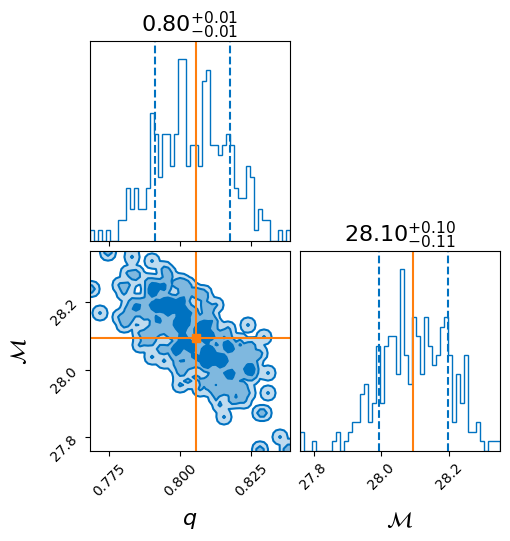

In [14]:
#Run sampler.  In this case we're going to use the `dynesty` sampler which employes nested sampling 
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler="dynesty",# this sampler uses nested sampling   
    nlive=100,#these settings are not sufficient for conversion 
    naccept=5,#these settings are not sufficient for conversion 
    sample="acceptance-walk",
    injection_parameters=injection_parameters,
    outdir=outdir,
    label=label,
    clean=True, # Switch this to False if you want to be able to checkpoint and restart your run. 
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    result_class=bilby.gw.result.CBCResult,
)
result.plot_corner(save = False)
result.plot_waveform_posterior(n_samples=1000)
from IPython.display import Image
Image(filename='outdir/fast_tutorial_H1_waveform.png')

## Questions

What happens when you inject into noise? 

Restart the notebook and inject into noise again. What changes?

What happens if you change the prior bounds so they exclude the injection? 

Can you change the code so that you sample on different parameters? 

What happens if you change the luminosity distance? 